In [12]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score 




In [16]:
url= "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
cols = ['Area', 'Perimeter', 'Compactness', 'Kernel_length', 'Kernel_Width', 'Assymetry', 'Groove','Variety']
df= pd.read_csv(url, names=cols, sep='\s+')

<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\karam\AppData\Local\Temp\ipykernel_17736\1838059187.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df= pd.read_csv(url, names=cols, sep='\s+')


In [17]:
df.head()

,Area,Perimeter,Compactness,Kernel_length,Kernel_Width,Assymetry,Groove,Variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


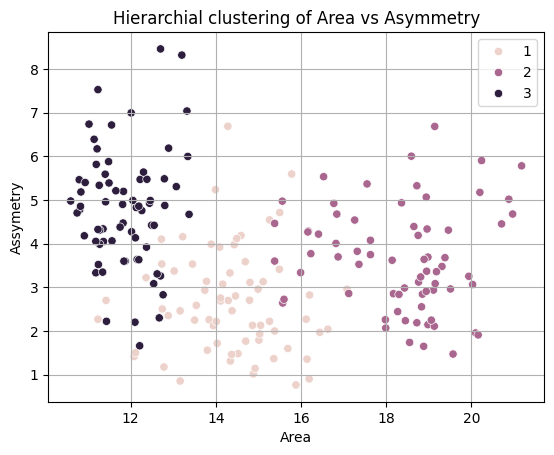

In [ ]:
sns.scatterplot(data=df, x='Area', y ='Assymetry', hue='Variety')
plt.title("Scatterplot of Area vs Asymmetry")
plt.grid(True)
plt.legend()
plt.show()

In [24]:
X = df.drop(columns='Variety')
true_labels=df['Variety']

In [25]:
s=StandardScaler()

In [26]:
scaled_X=s.fit_transform(X)


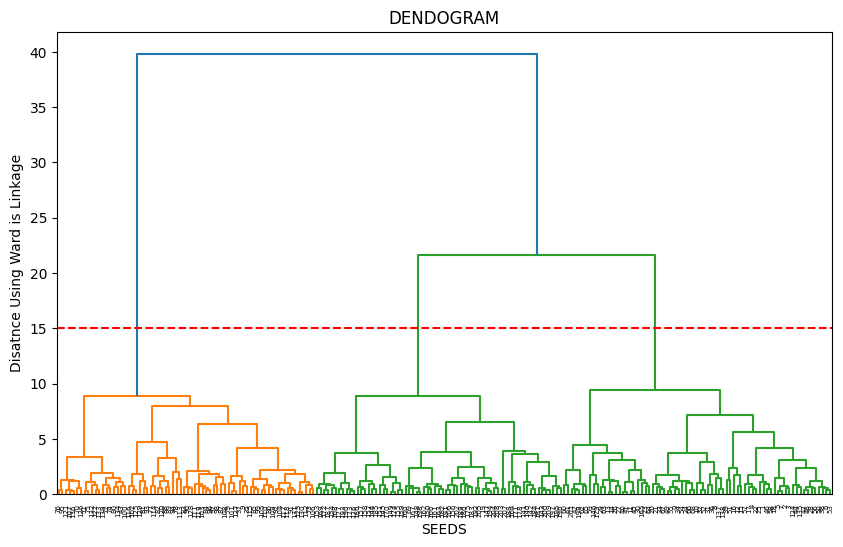

In [27]:
plt.figure(figsize=(10,6))
plt.title("DENDOGRAM")
d=sch.dendrogram(sch.linkage(scaled_X, method='ward'))
plt.axhline(y=15,color='red',linestyle="--")
plt.xlabel("SEEDS")
plt.ylabel("Disatnce Using Ward is Linkage")
plt.show()

In [29]:
cluster = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage='ward')
df["C_labels"]= cluster.fit_predict(scaled_X)

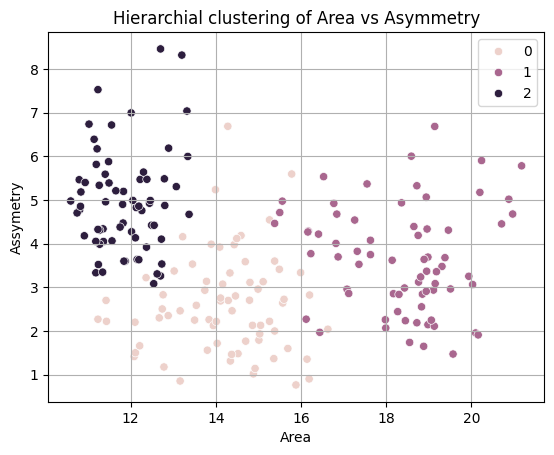

In [31]:
sns.scatterplot(data=df, x='Area', y ='Assymetry', hue='C_labels')
plt.title("Hierarchial clustering of Area vs Asymmetry")
plt.grid(True)
plt.legend()
plt.show()

In [32]:
score=silhouette_score(scaled_X,df['C_labels'])

In [33]:
print(f"Silhouette Score:{score:.3f}")

Silhouette Score:0.393
